In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/UIT/CS114/model 8

/content/drive/MyDrive/UIT/CS114/model 8


#Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/UIT/CS114/Wecode/annonimized.csv')
df = df.rename(columns={
    "concat('it001', username)": "hash",
    "concat('it001',`assignment_id`)": "assignment_id",
    "concat('it001',`problem_id`)": "problem_id",
    "pre_score": "score",
    "coefficient": "late_coef",
    "created_at": "submit_time",
    "updated_at": "judge_time",
    "concat('it001',`language_id`)": "lang_id",
    "judgement": "judgement_json"
})
df['submit_time'] = pd.to_datetime('2024-' + df['submit_time'], errors='coerce')
df['judge_time'] = pd.to_datetime('2024-' + df['judge_time'], errors='coerce')
custom_map = {
    'SCORE': 3,               # tốt nhất
    'pending': 2,
    'Syntax Error': 1,
    'Compilation Error': 0    # tệ nhất
}
df['status'] = df['status'].map(custom_map)
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
for col in ['assignment_id', 'problem_id', 'lang_id']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
df = df_encoded.drop(columns=['judgement_json'])

In [ ]:
df.head(5)

,assignment_id,problem_id,hash,is_final,status,score,late_coef,lang_id,submit_time,judge_time
0,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:02:04,2024-10-09 08:06:58
1,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:04:41,2024-10-09 08:04:51
2,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:06:49,2024-10-09 08:06:58
3,116,335,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:47:52,2024-10-09 08:48:01
4,116,212,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 09:19:35,2024-10-09 09:19:45


In [ ]:
df_qt =  pd.read_csv('/content/drive/MyDrive/UIT/CS114/Wecode/qt-public.csv')
#chuyển TH thành dạng float
df_qt['diemqt'] = pd.to_numeric(df_qt['diemqt'], errors='coerce')
df_qt = df_qt.dropna(subset=['diemqt'])

In [ ]:
df_qt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 754 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hash    754 non-null    object 
 1   diemqt  754 non-null    float64
dtypes: float64(1), object(1)
memory usage: 17.7+ KB


In [ ]:
# Bước 1: Lấy toàn bộ sinh viên
df_all_features = df[['hash']].drop_duplicates().copy()
# Bước 2: Feature engineering (giống trước)
# Tổng số bài nộp
submission_counts = df.groupby('hash').size().reset_index(name='submit_count')
df_all_features = df_all_features.merge(submission_counts, on='hash', how='left')
df_all_features['submit_count'] = df_all_features['submit_count'].fillna(0).astype(int)

# Tổng số bài is_final
df_final = df[df['is_final'] == 1]
final_submit_count = df_final.groupby('hash').size().reset_index(name='final_submit_count')
df_all_features = df_all_features.merge(final_submit_count, on='hash', how='left')
df_all_features['final_submit_count'] = df_all_features['final_submit_count'].fillna(0).astype(int)

# Trung bình điểm is_final
avg_final_score = df_final.groupby('hash')['score'].mean().reset_index(name='avg_final_score')
df_all_features = df_all_features.merge(avg_final_score, on='hash', how='left')
df_all_features['avg_final_score'] = df_all_features['avg_final_score'].fillna(0)

# Đếm status
status_counts = df.groupby(['hash', 'status']).size().unstack(fill_value=0)
status_counts.columns = [f'count_status_{int(col)}' for col in status_counts.columns]
df_all_features = df_all_features.merge(status_counts, on='hash', how='left')
df_all_features[status_counts.columns] = df_all_features[status_counts.columns].fillna(0).astype(int)

# Đếm số ngôn ngữ
lang_count = df.groupby('hash')['lang_id'].nunique().reset_index(name='lang_count')
df_all_features = df_all_features.merge(lang_count, on='hash', how='left')
df_all_features['lang_count'] = df_all_features['lang_count'].fillna(0).astype(int)

# Trung bình hệ số trễ
avg_late_coef = df.groupby('hash')['late_coef'].mean().reset_index(name='avg_late_coef')
df_all_features = df_all_features.merge(avg_late_coef, on='hash', how='left')
df_all_features['avg_late_coef'] = df_all_features['avg_late_coef'].fillna(0)

# Trung bình số lần nộp lại mỗi bài
submit_counts = df.groupby(['hash', 'problem_id']).size().reset_index(name='submission_count')
avg_resubmit = submit_counts.groupby('hash')['submission_count'].mean().reset_index(name='avg_submission_per_problem')
df_all_features = df_all_features.merge(avg_resubmit, on='hash', how='left')
df_all_features['avg_submission_per_problem'] = df_all_features['avg_submission_per_problem'].fillna(0)

# Trung bình thời gian làm bài
earliest = df[['hash', 'problem_id', 'submit_time']].groupby(['hash', 'problem_id'], as_index=False).min()
latest = df[['hash', 'problem_id', 'judge_time']].groupby(['hash', 'problem_id'], as_index=False).max()
time_diff = earliest.merge(latest, on=['hash', 'problem_id'])
time_diff['time'] = (time_diff['judge_time'] - time_diff['submit_time']).dt.total_seconds()
average_time = time_diff.groupby('hash', as_index=False)['time'].mean().rename(columns={'time': 'average_time'})
df_all_features = df_all_features.merge(average_time, on='hash', how='left')
df_all_features['average_time'] = df_all_features['average_time'].fillna(0).astype(int)

# Thêm cột điểm thực hành
df_all_features = df_all_features.merge(df_qt, on='hash', how='left')
df_all_features.drop(columns=['count_status_2','count_status_1','lang_count'], inplace=True)
df_all_features.to_csv('df_all_features.csv', index=False)

In [ ]:
df_all_features.head(5)

,hash,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_3,avg_late_coef,avg_submission_per_problem,average_time,diemqt
0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,139,58,9801.724138,34,105,100.0,2.396552,6418,NaN
1,ba12c0a2cb367af0467e479c03507c71a805d291,319,117,10000.000000,74,245,100.0,2.848214,909848,NaN
2,0bd2037bf68a97753e5e67ab55dac026a649f279,220,54,9084.166667,57,163,100.0,4.074074,106527,6.0
3,b7298b0fe50443a623af9b56792b330c2d052845,247,110,9911.881818,36,211,100.0,2.245455,603250,NaN
4,c60be70309789b39355dc612f36e37090ccad5dc,172,83,9722.891566,26,146,100.0,2.072289,20048,NaN


#Train Model

In [ ]:
!pip install xgboost scikit-learn

In [ ]:
df_train = df_all_features[df_all_features['diemqt'].notna()].copy()

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np


X = df_train.drop(columns=['hash', 'diemqt'])
y = df_train['diemqt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Khởi tạo mô hình
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Lưới tham số cần thử
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Huấn luyện
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='r2', verbose=1)

In [ ]:
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best Score (R2):", grid_search.best_score_)
# Đánh giá trên tập test
y_test_pred = best_model.predict(X_test)
test_mse = (mean_squared_error(y_test, y_test_pred))
print(f"MSE trên tập test: {test_mse:.4f}")
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_test_pred)
print(f"R² score = {r2:.4f}")

Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6}
Best Score (R2): 0.06485043734268423
MSE trên tập test: 2.5678
R² score = 0.1412


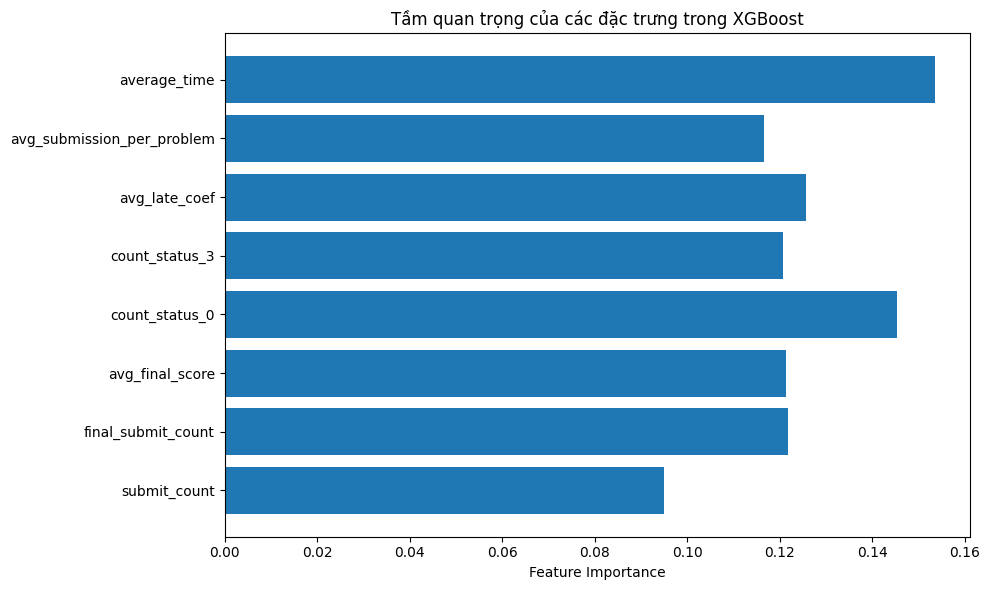

In [ ]:
importances = best_model.feature_importances_
features = X.columns
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Tầm quan trọng của các đặc trưng trong XGBoost")
plt.tight_layout()
plt.show()

#Lưu Model

In [ ]:
import joblib
# Lưu best model (vừa tìm được)
joblib.dump(best_model, 'best_model.pkl')
print("✅ Mô hình đã được lưu vào file: best_model.pkl")


✅ Mô hình đã được lưu vào file: best_model.pkl


In [ ]:
X_all = df_all_features.drop(columns=['hash', 'diemqt', 'diemqt_predicted'], errors='ignore')
df_all_features['diemqt_predicted'] = best_model.predict(X_all)
df_all_features[['hash', 'diemqt_predicted']].to_csv('result.csv', index=False)